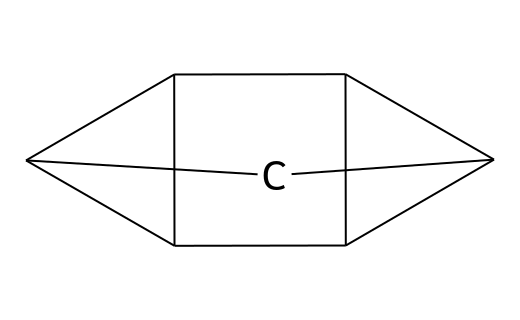

In [15]:
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

inchi = "InChI=1S/C14H24/c1-11-8-9-12(2,10-11)14(4)7-5-6-13(11,14)3/h5-10H2,1-4H3/t11-,12+,13+,14-"
inchi = "InChI=1S/C7H8/c1-2-4-5(2)7-3(1)6(4)7/h2-7H,1H2"

mol = Chem.MolFromInchi(inchi, removeHs=False)
if mol is None:
    raise ValueError("Failed to parse InChI.")

display(Draw.MolToImage(mol, size=(520, 320)))

StereoMolGraph
Atoms
(0 O) (1 C) (2 C) (3 C) (4 C) (5 C) (6 H) (7 H) (8 H) (9 H) (10 H)
(11 H) (12 H) (13 H) (14 H)
Bonds
(0 1) (0 6) (1 2) (1 7) (1 8) (2 3) (2 9) (3 4) (3 5) (4 10) (4 11) (4 12) (5 13) (5 14)
Atom Stereo {1: Tetrahedral((1 0 2 7 8) -1) 4: Tetrahedral((4 3 10 11 12) 1)}
Bond Stereo {(2 3): PlanarBond((1 9 2 3 4 5) 0) (3 5): PlanarBond((2 4 3 5 13 14) 0)}


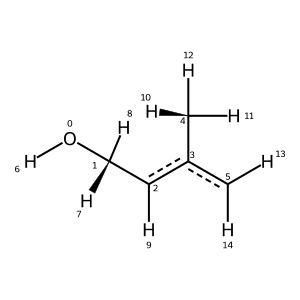

StereoMolGraph
Atoms
(0 O) (1 C) (2 C) (3 C) (4 C) (5 C) (6 H) (7 H) (8 H) (9 H) (10 H)
(11 H) (12 H) (13 H) (14 H)
Bonds
(0 1) (0 6) (1 2) (1 7) (1 8) (2 3) (2 9) (3 4) (3 5) (4 10) (4 11) (4 12) (5 13) (5 14)
Atom Stereo {1: Tetrahedral((1 0 2 7 8) -1) 4: Tetrahedral((4 3 10 11 12) 1)}
Bond Stereo {(2 3): PlanarBond((1 9 2 3 5 4) 0) (3 5): PlanarBond((2 4 3 5 13 14) 0)}


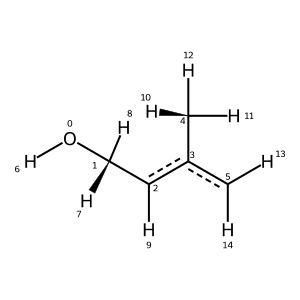

In [ ]:
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

from stereomolgraph.experimental import generate_stereoisomers
from stereomolgraph.ipython import View2D
from stereomolgraph.rdmol2graph import RDMol2StereoMolGraph

View2D.generate_bond_orders = False

rdmol = Chem.AddHs(Chem.MolFromSmiles(r"OC/C=C(\C)/[CH2]"))

converter = RDMol2StereoMolGraph(
    stereo_complete=False, lone_pair_stereo=False, resonance=True
)

smg = converter(rdmol)

stereoisomers = list(
    generate_stereoisomers(
        smg,
        atoms=smg.atom_stereo.keys(),
        bonds=smg.bond_stereo.keys(),
        enantiomers=False,
    )
)

for isomer in stereoisomers:
    print(repr(isomer))
    display(isomer)